In [1]:
# Cell 1: 套件與輔助函式
import os
import pandas as pd
import numpy as np
import datetime
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import roc_auc_score, roc_curve, log_loss
from tensorflow.keras.preprocessing.sequence import pad_sequences

try:
    from deepctr.feature_column import SparseFeat, DenseFeat, VarLenSparseFeat, get_feature_names
    from deepctr.models import DeepFM
    from tensorflow.keras.optimizers import Adam
    DEEPCTR_AVAILABLE = True
except ImportError:
    print("警告: deepctr 或 tensorflow 未安裝。請執行 'pip install deepctr tensorflow'")
    DEEPCTR_AVAILABLE = False

try:
    from lifelines import WeibullAFTFitter
    LIFELINES_AVAILABLE = True
except ImportError:
    print("警告: lifelines 未安裝。請執行 'pip install lifelines'")
    LIFELINES_AVAILABLE = False

try:
    from user_agents import parse as ua_parse
    USER_AGENTS_AVAILABLE = True
except ImportError:
    print("警告: user_agents 未安裝。請執行 'pip install pyyaml ua-parser user-agents'")
    USER_AGENTS_AVAILABLE = False

warnings.filterwarnings('ignore')

def parse_user_agent(ua_str):
    ua = ua_parse(str(ua_str))
    browser = ua.browser.family or "Unknown"
    os_family = ua.os.family or "Unknown"
    if ua.is_mobile:
        device_type = "Mobile"
    elif ua.is_tablet:
        device_type = "Tablet"
    elif ua.is_pc:
        device_type = "PC"
    else:
        device_type = "Other"
    return pd.Series([browser, os_family, device_type])

def parse_ad_slot_id(slot_id):
    s = str(slot_id)
    result = {
        'slot_p1': None, 'slot_p2': None, 'slot_p3': None,
        'slot_platform': None, 'slot_platform_id1': None, 'slot_platform_id2': None,
        'slot_category': None, 'slot_flag': None, 'slot_width_tier': None,
        'slot_numeric_id': None, 'slot_unknown_id': None
    }
    if s.startswith('mm_'):
        parts = s.split('_')
        if len(parts) == 4:
            result['slot_p1'], result['slot_p2'], result['slot_p3'] = parts[1], parts[2], parts[3]
        else:
            result['slot_unknown_id'] = s
    elif any(s.startswith(prefix) for prefix in ['discuz_', 'phpwind_', 'dz_', 'pw_']):
        parts = s.split('_')
        result['slot_platform'] = parts[0]
        if len(parts) > 1: result['slot_platform_id1'] = parts[1]
        if len(parts) > 2: result['slot_platform_id2'] = parts[2]
    elif s.isdigit():
        result['slot_numeric_id'] = s
    elif '_' in s:
        parts = s.split('_')
        result['slot_category'] = parts[0]
        remaining_parts = parts[1:]
        temp_flag = []
        for part in remaining_parts:
            if part.startswith('Width'):
                result['slot_width_tier'] = part
            elif len(part) == 1 and part.isupper():
                temp_flag.append(part)
        if temp_flag:
            result['slot_flag'] = '_'.join(temp_flag)
    else:
        result['slot_unknown_id'] = s
    return pd.Series(result)

In [2]:
# Cell 2: 參數與初始化
student_id = "M36134016"
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"bidding_system_run_{timestamp}"
ctr_viz_dir = os.path.join(output_dir, "ctr_model_visualization")
wp_viz_dir = os.path.join(output_dir, "winprice_model_visualization")
os.makedirs(ctr_viz_dir, exist_ok=True)
os.makedirs(wp_viz_dir, exist_ok=True)

base_bid = 65
DAY_BUDGET = 5000

encoders = {}
scalers = {}
user_tags_vocab = {'<PAD>': 0}
user_tags_max_len = 0
deepctr_feature_columns = []
deepctr_feature_names = None
ctr_model = None
winprice_model = None
avg_ctr = 0.0

In [3]:
# Cell 3: 特徵工程
def preprocess_features(df, is_train=True):
    global user_tags_vocab, user_tags_max_len, encoders, scalers
    print(f"開始特徵預處理 (is_train={is_train})...")
    df_processed = df.copy()
    for col in ['anonymous_url_id', 'key_page_url', 'bid_id']:
        if col in df_processed.columns:
            df_processed = df_processed.drop(col, axis=1)
    # 時間特徵
    if np.issubdtype(df_processed['timestamp'].dtype, np.number):
        df_processed['timestamp_dt'] = pd.to_datetime(df_processed['timestamp'], unit='s')
    else:
        df_processed['timestamp_dt'] = pd.to_datetime(df_processed['timestamp'], errors='coerce')
    df_processed['hour'] = df_processed['timestamp_dt'].dt.hour
    df_processed['day_of_week'] = df_processed['timestamp_dt'].dt.dayofweek
    # User Agent
    
    ua_features = df_processed['user_agent'].apply(parse_user_agent)
    ua_features.columns = ['browser', 'os', 'device_type']
    df_processed = pd.concat([df_processed, ua_features], axis=1)
    # Ad Slot ID
    ad_slot_features = df_processed['ad_slot_id'].apply(parse_ad_slot_id)
    df_processed = pd.concat([df_processed, ad_slot_features], axis=1)
    # ad_slot_size
    df_processed['ad_slot_size'] = df_processed['ad_slot_width'] * df_processed['ad_slot_height']
    # User Tags
    df_processed['user_tags'] = df_processed['user_tags'].fillna('').astype(str)
    tags_list = df_processed['user_tags'].apply(lambda x: x.split(',') if x else [])
    if is_train:
        all_tags = [tag for sublist in tags_list for tag in sublist if tag]
        for tag in all_tags:
            if tag not in user_tags_vocab:
                user_tags_vocab[tag] = len(user_tags_vocab)
        user_tags_max_len = max(len(x) for x in tags_list)
    tags_seq = tags_list.apply(lambda t_list: [user_tags_vocab.get(t, 0) for t in t_list])
    df_processed['user_tags_seq'] = list(pad_sequences(tags_seq, maxlen=user_tags_max_len, padding='post'))
    categorical_features = [
        'domain', 'ip', 'city', 'region', 'ad_exchange', 'ad_slot_format',
        'ad_slot_visibility', 'creative_id', 'browser', 'os', 'device_type',
        'hour', 'day_of_week', 'slot_p1', 'slot_p2', 'slot_p3', 'slot_platform',
        'slot_platform_id1', 'slot_platform_id2', 'slot_category', 'slot_flag',
        'slot_width_tier', 'slot_numeric_id', 'slot_unknown_id'
    ]
    numerical_features = ['ad_slot_width', 'ad_slot_height', 'ad_slot_floor_price', 'ad_slot_size']
    # 類別特徵
    for col in categorical_features:
        df_processed[col] = df_processed[col].fillna('NULL').astype(str)
        if is_train:
            encoders[col] = LabelEncoder().fit(df_processed[col])
        # 修正：確保 'NULL' 在 classes_ 中
        if not is_train and 'NULL' not in encoders[col].classes_:
            encoders[col].classes_[0] = 'NULL'
            encoders[col].classes_.sort()
        known_classes = set(encoders[col].classes_)
        df_processed[col] = df_processed[col].apply(lambda x: x if x in known_classes else 'NULL')
        df_processed[col] = encoders[col].transform(df_processed[col])
    # 數值特徵
    for col in numerical_features:
        df_processed[col] = df_processed[col].fillna(0)
        if is_train:
            scalers[col] = MinMaxScaler().fit(df_processed[[col]])
        df_processed[col] = scalers[col].transform(df_processed[[col]])
    print("特徵預處理完成。")
    return df_processed, categorical_features, numerical_features

In [4]:
# Cell 4: 載入與預處理訓練資料
train_df_raw = pd.read_csv(r'C:\Users\ian32\Downloads\final\data\train.csv')
print(f"成功讀取 train.csv，共 {len(train_df_raw)} 筆資料。")
train_df, cat_feats, num_feats = preprocess_features(train_df_raw, is_train=True)

成功讀取 train.csv，共 1760309 筆資料。
開始特徵預處理 (is_train=True)...
特徵預處理完成。


In [5]:
# # Cell X: Feature and Click Relationship Analysis

# import matplotlib.pyplot as plt
# import seaborn as sns

# # 1. Categorical features vs. click (average click rate)
# for col in cat_feats:
#     plt.figure(figsize=(8, 4))
#     ctr = train_df.groupby(col)['click'].mean()
#     ctr.plot(kind='bar')
#     plt.title(f"Average Click Rate by {col}")
#     plt.ylabel("Average Click")
#     plt.xlabel(col)
#     plt.tight_layout()
#     plt.show()

# # 2. Numerical features vs. click (binned average click rate)
# for col in num_feats:
#     plt.figure(figsize=(8, 4))
#     # Binning
#     train_df[f'{col}_bin'] = pd.qcut(train_df[col].rank(method='first'), q=10, duplicates='drop')
#     ctr = train_df.groupby(f'{col}_bin')['click'].mean()
#     ctr.plot(marker='o')
#     plt.title(f"Binned {col} vs. Average Click Rate")
#     plt.ylabel("Average Click")
#     plt.xlabel(f"{col} Bin")
#     plt.tight_layout()
#     plt.show()

# # 3. Pearson correlation between numerical features and click
# corrs = train_df[num_feats + ['click']].corr()['click'].sort_values(ascending=False)
# print("Pearson correlation between numerical features and click:")

In [6]:
# import pickle
# train_df.to_pickle("train_df.pkl")
# with open("cat_feats.pkl", "wb") as f:
#     pickle.dump(cat_feats, f)
# with open("num_feats.pkl", "wb") as f:
#     pickle.dump(num_feats, f)
# with open("encoders.pkl", "wb") as f:
#     pickle.dump(encoders, f)
# with open("scalers.pkl", "wb") as f:
#     pickle.dump(scalers, f)
# with open("user_tags_vocab.pkl", "wb") as f:
#     pickle.dump(user_tags_vocab, f)
# with open("user_tags_max_len.pkl", "wb") as f:
#     pickle.dump(user_tags_max_len, f)

In [7]:
# # 建議放在 Cell 5 前面單獨一格
# from sklearn.model_selection import train_test_split

# # 分割訓練/驗證集
# X_train, X_val, y_train, y_val = train_test_split(train_df, train_df['click'], test_size=0.2, random_state=42)

# import tensorflow as tf

# def build_and_train_deepfm(embedding_dim, learning_rate, batch_size, epochs):
#     # 特徵欄位
#     sparse_features = [SparseFeat(feat, vocabulary_size=len(encoders[feat].classes_), embedding_dim=embedding_dim) for feat in cat_feats]
#     dense_features = [DenseFeat(feat, 1) for feat in num_feats]
#     varlen_features = [VarLenSparseFeat(SparseFeat('user_tags_seq', vocabulary_size=len(user_tags_vocab), embedding_dim=embedding_dim), maxlen=user_tags_max_len, combiner='mean')]
#     feature_columns = sparse_features + dense_features + varlen_features
#     feature_names = get_feature_names(feature_columns)
#     # 輸入
#     train_input = {name: X_train[name] for name in feature_names if name != 'user_tags_seq'}
#     train_input['user_tags_seq'] = np.vstack(X_train['user_tags_seq'].values)
#     val_input = {name: X_val[name] for name in feature_names if name != 'user_tags_seq'}
#     val_input['user_tags_seq'] = np.vstack(X_val['user_tags_seq'].values)
#     # 模型
#     model = DeepFM(feature_columns, feature_columns, task='binary')
#     model.compile("adam", "binary_crossentropy", metrics=['AUC'])
#     model.fit(train_input, y_train, batch_size=batch_size, epochs=epochs, verbose=0)
#     val_pred = model.predict(val_input, batch_size=batch_size).flatten()
#     auc = roc_auc_score(y_val, val_pred)
#     return auc, model, feature_columns, feature_names

# # 超參數搜尋空間
# embedding_dims = [4, 8]
# learning_rates = [0.001, 0.005]
# batch_sizes = [1024, 2048]
# epochs_list = [2, 3]

# best_auc = 0
# best_params = None
# best_model = None
# best_feature_columns = None
# best_feature_names = None

# for emb in embedding_dims:
#     for lr in learning_rates:
#         for bs in batch_sizes:
#             for ep in epochs_list:
#                 print(f"嘗試參數: embedding_dim={emb}, lr={lr}, batch_size={bs}, epochs={ep}")
#                 auc, model, feature_columns, feature_names = build_and_train_deepfm(emb, lr, bs, ep)
#                 print(f"驗證集AUC: {auc:.5f}")
#                 if auc > best_auc:
#                     best_auc = auc
#                     best_params = (emb, lr, bs, ep)
#                     best_model = model
#                     best_feature_columns = feature_columns
#                     best_feature_names = feature_names

# print(f"最佳參數: embedding_dim={best_params[0]}, lr={best_params[1]}, batch_size={best_params[2]}, epochs={best_params[3]}")
# print(f"最佳驗證集AUC: {best_auc:.5f}")

# # 用最佳參數與模型繼續後續流程
# ctr_model = best_model
# deepctr_feature_columns = best_feature_columns
# deepctr_feature_names = best_feature_names

# # 若要在全訓練集上再訓練一次，可再 fit 一次

In [8]:
# ...existing code...

from tensorflow.keras.callbacks import EarlyStopping

# 直接指定最佳參數
best_embedding_dim = 4
best_lr = 0.005
best_bs = 1024
best_epochs = 2

sparse_features = [SparseFeat(feat, vocabulary_size=len(encoders[feat].classes_), embedding_dim=best_embedding_dim) for feat in cat_feats]
dense_features = [DenseFeat(feat, 1) for feat in num_feats]
varlen_features = [VarLenSparseFeat(SparseFeat('user_tags_seq', vocabulary_size=len(user_tags_vocab), embedding_dim=best_embedding_dim), maxlen=user_tags_max_len, combiner='mean')]
deepctr_feature_columns = sparse_features + dense_features + varlen_features
deepctr_feature_names = get_feature_names(deepctr_feature_columns)

train_model_input = {name: train_df[name] for name in deepctr_feature_names if name != 'user_tags_seq'}
train_model_input['user_tags_seq'] = np.vstack(train_df['user_tags_seq'].values)

ctr_model = DeepFM(deepctr_feature_columns, deepctr_feature_columns, task='binary')
ctr_model.compile("adam", "binary_crossentropy", metrics=['binary_crossentropy', 'AUC'])
target = ['click']
y_train = train_df[target]

early_stopping = EarlyStopping(monitor='val_auc', patience=2, mode='max', restore_best_weights=True)

history = ctr_model.fit(
    train_model_input, y_train,
    batch_size=best_bs,
    epochs=best_epochs,
    verbose=1,
    validation_split=0.2,
    callbacks=[early_stopping]
)

# 分批預測以降低記憶體用量
def batch_predict(model, model_input, batch_size=4096):
    n = len(next(iter(model_input.values())))
    preds = []
    for i in range(0, n, batch_size):
        batch = {k: v[i:i+batch_size] for k, v in model_input.items()}
        preds.append(model.predict(batch, batch_size=batch_size).flatten())
    return np.concatenate(preds)

all_pctr_preds = batch_predict(ctr_model, train_model_input, batch_size=best_bs)
avg_ctr = np.mean(all_pctr_preds)
print(f"pCTR 模型訓練完成。平均 pCTR (avgCTR) = {avg_ctr:.6f}")
ctr_model.save(os.path.join(output_dir, "deepfm_model.h5"))
# ...existing code...

Epoch 1/2
1376/1376 [==============================] - 76s 44ms/step - loss: 0.0125 - binary_crossentropy: 0.0124 - auc: 0.6014 - val_loss: 0.0026 - val_binary_crossentropy: 0.0025 - val_auc: 0.9253
Epoch 2/2
1376/1376 [==============================] - 57s 41ms/step - loss: 0.0043 - binary_crossentropy: 0.0039 - auc: 0.7524 - val_loss: 0.0025 - val_binary_crossentropy: 0.0021 - val_auc: 0.9564
pCTR 模型訓練完成。平均 pCTR (avgCTR) = 0.001167


In [9]:
# Cell 6: 訓練得標價格模型（自動搜尋最佳分布型態）
from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter

# ...existing code...
win_df = train_df.copy()
win_df['event'] = 1
# 修正這一行，確保 duration 全部為正
win_df['duration'] = np.where(win_df['paying_price'] > 0, win_df['paying_price'], 1e-3)
# ...existing code...
features_for_winprice = cat_feats + num_feats

aft_models = {
    "Weibull": WeibullAFTFitter(),
    "LogNormal": LogNormalAFTFitter(),
    "LogLogistic": LogLogisticAFTFitter()
}

best_aic = float('inf')
best_model = None
best_name = None

for name, model in aft_models.items():
    model.fit(win_df[features_for_winprice + ['duration', 'event']], 'duration', event_col='event')
    aic = model.AIC_
    print(f"{name} AIC: {aic}")
    if aic < best_aic:
        best_aic = aic
        best_model = model
        best_name = name

print(f"最佳AFT模型: {best_name} (AIC={best_aic})")
winprice_model = best_model
winprice_model.print_summary()

plt.figure(figsize=(12, 7))
winprice_model.plot()
plt.title(f"{best_name} AFT Model - Parameter Coefficients")
plt.tight_layout()
plt.savefig(os.path.join(wp_viz_dir, "01_coefficients.png"))
plt.close()

Weibull AIC: 17935569.81828929
LogNormal AIC: 17839884.654438585
LogLogistic AIC: 17757452.739203364
最佳AFT模型: LogLogistic (AIC=17757452.739203364)


<lifelines.LogLogisticAFTFitter: fitted with 1.76031e+06 total observations, 0 right-censored observations>
             duration col = 'duration'
                event col = 'event'
   number of observations = 1.76031e+06
number of events observed = 1.76031e+06
           log-likelihood = -8878696.37
         time fit was run = 2025-06-25 11:16:23 UTC

---
                             coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
param  covariate                                                                                                                   
alpha_ ad_exchange          -0.90       0.41       0.01            -0.92            -0.88                 0.40                 0.41
       ad_slot_floor_price   3.19      24.24       0.01             3.18             3.20                23.94                24.54
       ad_slot_format       -0.77       0.46       0.01            -0.79            -0.75                 0.45                 0.47
       ad_slot_height       -0.96       0.38       0.01            -0.97            -0.94                 0.38                 0.39
       ad_slot_size          0.54       1.71       0.01             0.53             0.55                 1.69                 1.73
       ad_slot_visibility    0.01       1.01       0.00             0.01             0.01                 1.01                 1.01
       ad_slot_width        -0.60       0.55       0.00            -0.61            -0.59                 0.54                 0.55
       browser              -0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
       city                 -0.00       1.00       0.00            -0.00            -0.00                 1.00                 1.00
       creative_id           0.03       1.03       0.00             0.03             0.03                 1.03                 1.04
       day_of_week           0.03       1.03       0.00             0.03             0.03                 1.03                 1.03
       device_type          -0.07       0.93       0.00            -0.08            -0.06                 0.93                 0.94
       domain                0.00       1.00       0.00             0.00             0.00                 1.00                 1.00
       hour                 -0.00       1.00       0.00            -0.00            -0.00                 1.00                 1.00
       ip                    0.00       1.00       0.00             0.00             0.00                 1.00                 1.00
       os                    0.00       1.00       0.00             0.00             0.00                 1.00                 1.00
       region                0.00       1.00       0.00             0.00             0.00                 1.00                 1.00
       slot_category         0.00       1.00       0.00             0.00             0.00                 1.00                 1.00
       slot_flag            -0.54       0.58       0.01            -0.55            -0.53                 0.58                 0.59
       slot_numeric_id       0.00       1.00       0.00             0.00             0.00                 1.00                 1.00
       slot_p1               0.00       1.00       0.00             0.00             0.00                 1.00                 1.00
       slot_p2              -0.01       0.99       0.00            -0.01            -0.01                 0.99                 0.99
       slot_p3               0.00       1.00       0.00             0.00             0.00                 1.00                 1.00
       slot_platform         0.84       2.32       0.03             0.79             0.89                 2.21                 2.44
       slot_platform_id1    -0.02       0.98       0.00            -0.02            -0.02                 0.98                 0.98
       slot_platform_id2     0.14       1.15       0.00             0.13    

訓練集預測得標價格統計：
  平均值: 55.63
  標準差: 38.23
  最小值: 6.58
  最大值: 1131.88


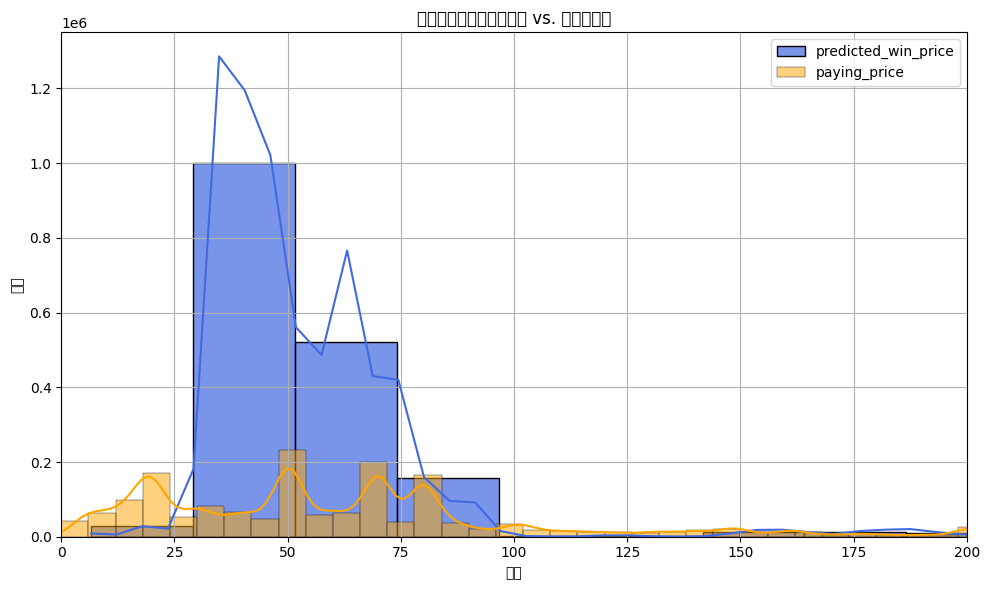

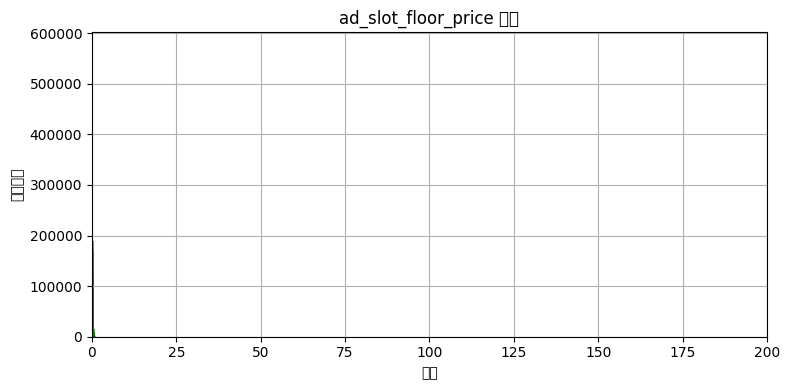

In [15]:
# Cell X: 改善得標價格分布視覺化

import matplotlib.pyplot as plt
import seaborn as sns

train_predicted_win_prices = winprice_model.predict_median(train_df[features_for_winprice])

print("訓練集預測得標價格統計：")
print(f"  平均值: {train_predicted_win_prices.mean():.2f}")
print(f"  標準差: {train_predicted_win_prices.std():.2f}")
print(f"  最小值: {train_predicted_win_prices.min():.2f}")
print(f"  最大值: {train_predicted_win_prices.max():.2f}")

plt.figure(figsize=(10, 6))
sns.histplot(train_predicted_win_prices, bins=50, kde=True, color='royalblue', label='predicted_win_price', alpha=0.7)
sns.histplot(train_df['paying_price'], bins=50, kde=True, color='orange', label='paying_price', alpha=0.5)
plt.title('訓練集得標價格預測分布 vs. 實際得標價')
plt.xlabel('價格')
plt.ylabel('頻率')
plt.xlim(0, 200)  # 限制 x 軸範圍
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 底價分布（用 bar）
plt.figure(figsize=(8, 4))
floor_counts = train_df['ad_slot_floor_price'].value_counts().sort_index()
plt.bar(floor_counts.index, floor_counts.values, color='green', alpha=0.7)
plt.title('ad_slot_floor_price 分布')
plt.xlabel('底價')
plt.ylabel('出現次數')
plt.xlim(0, 200)
plt.grid(True)
plt.tight_layout()
plt.show()

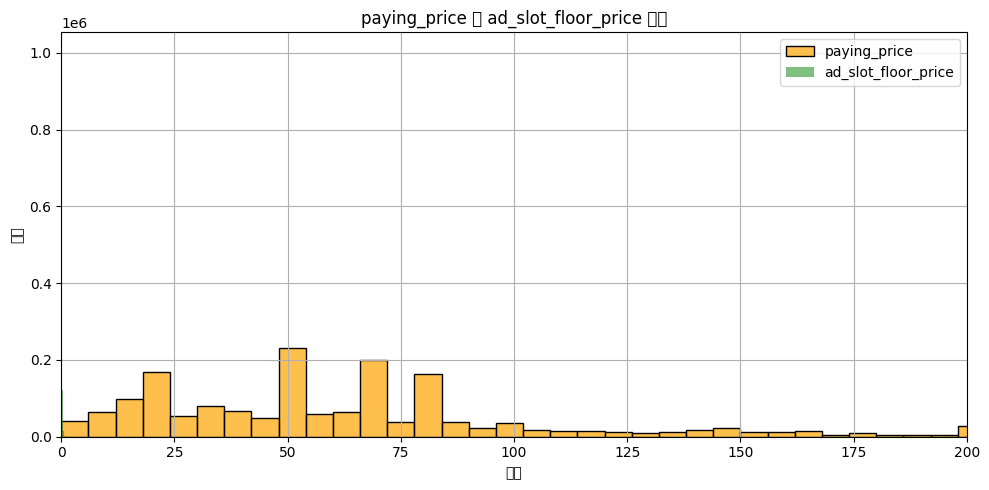

In [16]:
# Cell X: 檢查 paying_price/ad_slot_floor_price 分布
plt.figure(figsize=(10, 5))
sns.histplot(train_df['paying_price'], bins=50, color='orange', label='paying_price', alpha=0.7)
sns.histplot(train_df['ad_slot_floor_price'], bins=50, color='green', label='ad_slot_floor_price', alpha=0.5)
plt.title('paying_price 與 ad_slot_floor_price 分布')
plt.xlabel('價格')
plt.ylabel('頻率')
plt.xlim(0, 200)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
# # Cell 7: 視覺化
# pd.DataFrame(history.history).plot(figsize=(10, 6))
# plt.grid(True)
# plt.title('DeepFM Model Training History')
# plt.xlabel('Epoch')
# plt.ylabel('Metric Value')
# plt.savefig(os.path.join(ctr_viz_dir, "01_training_history.png"))
# plt.close()

# fpr, tpr, _ = roc_curve(y_train, all_pctr_preds)
# auc = roc_auc_score(y_train, all_pctr_preds)
# plt.figure(figsize=(10, 8))
# plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
# plt.plot([0, 1], [0, 1], 'k--')
# plt.title('ROC Curve')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.legend(loc='lower right')
# plt.grid()
# plt.savefig(os.path.join(ctr_viz_dir, "02_roc_curve.png"))
# plt.close()

# plt.figure(figsize=(10, 6))
# sns.histplot(all_pctr_preds, bins=50, kde=True)
# plt.title('pCTR Prediction Distribution on Training Data')
# plt.xlabel('Predicted pCTR')
# plt.ylabel('Frequency')
# plt.axvline(avg_ctr, color='r', linestyle='--', label=f'Avg CTR: {avg_ctr:.4f}')
# plt.legend()
# plt.savefig(os.path.join(ctr_viz_dir, "03_prediction_distribution.png"))
# plt.close()

   threshold  num_bids  total_clicks  avg_pctr    avg_pay  empirical_ctr
0      0.001    386874          1294  0.004215  78.653164       0.003345
1      0.005     18896          1236  0.049803  85.358489       0.065411
2      0.010      6555          1174  0.131245  84.527384       0.179100
3      0.020      3362          1049  0.242969  86.146936       0.312017
4      0.050      1921           812  0.402043  87.306091       0.422697
5      0.100      1388           695  0.530160  86.290346       0.500720


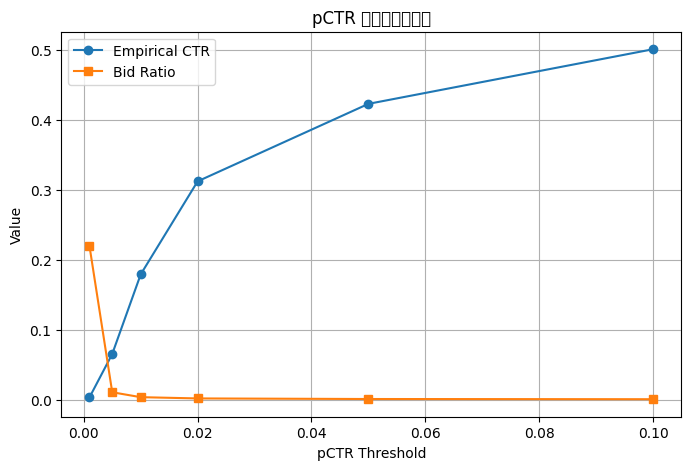

In [17]:
# Cell X: pCTR 閾值敏感度分析
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 預測訓練集 pCTR
train_model_input = {name: train_df[name] for name in deepctr_feature_names if name != 'user_tags_seq'}
train_model_input['user_tags_seq'] = np.vstack(train_df['user_tags_seq'].values)
train_pctr = batch_predict(ctr_model, train_model_input, batch_size=4096)

thresholds = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
results = []

for th in thresholds:
    mask = train_pctr >= th
    num_bids = mask.sum()
    total_clicks = train_df['click'][mask].sum()
    avg_pctr = train_pctr[mask].mean() if num_bids > 0 else 0
    avg_pay = train_df['paying_price'][mask].mean() if num_bids > 0 else 0
    ctr = total_clicks / num_bids if num_bids > 0 else 0
    results.append({
        'threshold': th,
        'num_bids': num_bids,
        'total_clicks': total_clicks,
        'avg_pctr': avg_pctr,
        'avg_pay': avg_pay,
        'empirical_ctr': ctr
    })

df_results = pd.DataFrame(results)
print(df_results)

plt.figure(figsize=(8,5))
plt.plot(df_results['threshold'], df_results['empirical_ctr'], marker='o', label='Empirical CTR')
plt.plot(df_results['threshold'], df_results['num_bids']/len(train_df), marker='s', label='Bid Ratio')
plt.xlabel('pCTR Threshold')
plt.ylabel('Value')
plt.title('pCTR 閾值敏感度分析')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Cell 8: 預測測試集並產生提交檔案（逐筆預算控管版）
import numpy as np
import pandas as pd

test_df_raw = pd.read_csv(r'C:\Users\ian32\Downloads\final\data\test_day3.csv')
print(f"成功讀取 test_day3.csv，共 {len(test_df_raw)} 筆資料。")
bid_ids = test_df_raw['bid_id']
test_df, _, _ = preprocess_features(test_df_raw, is_train=False)
test_model_input = {name: test_df[name] for name in deepctr_feature_names if name != 'user_tags_seq'}
test_model_input['user_tags_seq'] = np.vstack(test_df['user_tags_seq'].values)

# 分批預測測試集 pCTR
test_pctr = batch_predict(ctr_model, test_model_input, batch_size=4096)
test_df['predicted_ctr'] = test_pctr

# 分批預測得標價格
predicted_win_prices = winprice_model.predict_median(test_df[features_for_winprice])
test_df['predicted_win_price'] = predicted_win_prices

# 預算與時段控管
remaining_budget = DAY_BUDGET
spent_per_hour = [0] * 24
hourly_budget = [DAY_BUDGET // 24] * 24  # 可依需求調整分配

bid_results = []
num_bids_made = 0
total_spent_if_won = 0

for idx in range(len(test_df)):
    row = test_df.iloc[idx]
    bid_id = bid_ids.iloc[idx]
    current_hour = int(row.get('hour', 0))
    bid_price = 0

    if spent_per_hour[current_hour] >= hourly_budget[current_hour] or remaining_budget <= 0:
        bid_price = 0
    else:
        predicted_ctr = row['predicted_ctr']
        if predicted_ctr < 0.01:  # 可依需求調整閾值
            bid_price = 0
        else:
            predicted_win_price = row['predicted_win_price']
            if not np.isfinite(predicted_win_price) or predicted_win_price <= 0:
                predicted_win_price = 1
            ad_slot_floor_price = row['ad_slot_floor_price']
            # 出價必須大於等於底價
            potential_bid = max(int(predicted_win_price) + 1, int(ad_slot_floor_price), 1)
            if remaining_budget >= potential_bid and (spent_per_hour[current_hour] + potential_bid) <= hourly_budget[current_hour]:
                bid_price = potential_bid
            else:
                bid_price = 0

    if bid_price > 0:
        remaining_budget -= bid_price
        spent_per_hour[current_hour] += bid_price
        num_bids_made += 1
        total_spent_if_won += bid_price

    bid_results.append({'bid_id': bid_id, 'bidding_price': bid_price})

    if (idx + 1) % 50000 == 0:
        print(f"已處理 {idx + 1}/{len(test_df)} 筆, 剩餘預算: {remaining_budget}, 出價次數: {num_bids_made}")

submission_df = pd.DataFrame(bid_results)
submission_filename = f"{student_id}_day3.csv"
submission_path = os.path.join(output_dir, submission_filename)
submission_df.to_csv(submission_path, index=False)
print(f"競價完成！提交檔案已儲存至: {submission_path}")
print(f"總出價金額: {submission_df['bidding_price'].sum()} (預算上限: {DAY_BUDGET})")
print(f"總出價次數: {(submission_df['bidding_price'] > 0).sum()}")
print(f"剩餘預算: {remaining_budget}")
# ...existing code...

成功讀取 test_day3.csv，共 446650 筆資料。
開始特徵預處理 (is_train=False)...
特徵預處理完成。
已處理 50000/446650 筆, 剩餘預算: 3817, 出價次數: 29
已處理 100000/446650 筆, 剩餘預算: 2803, 出價次數: 52
已處理 150000/446650 筆, 剩餘預算: 2392, 出價次數: 62
已處理 200000/446650 筆, 剩餘預算: 2033, 出價次數: 69
已處理 250000/446650 筆, 剩餘預算: 1799, 出價次數: 74
已處理 300000/446650 筆, 剩餘預算: 1400, 出價次數: 82
已處理 350000/446650 筆, 剩餘預算: 993, 出價次數: 95
已處理 400000/446650 筆, 剩餘預算: 458, 出價次數: 110
競價完成！提交檔案已儲存至: bidding_system_run_20250625_180252\M36134016_day3.csv
總出價金額: 4812 (預算上限: 5000)
總出價次數: 115
剩餘預算: 188


In [18]:
import pandas as pd

# 讀取原始出價檔案
csv_path = r"C:\Users\ian32\Downloads\final\bidding_system_run_20250625_180252\M36134016_day3.csv"
df = pd.read_csv(csv_path)

# 找出有出價的資料
mask = df['bidding_price'] > 0
df_bids = df[mask].copy()

# 依出價由小到大排序
df_bids_sorted = df_bids.sort_values('bidding_price')

# 預算剩餘
remain = 188
add_amount = 2

# 建立一個新的 pay 欄位，預設等於原 bidding_price
df['paying_price'] = df['bidding_price']

# 依序分配剩餘預算
for idx in df_bids_sorted.index:
    if remain >= add_amount:
        df.loc[idx, 'paying_price'] += add_amount
        remain -= add_amount
    else:
        break

# 只保留 bid_id 與 paying_price 欄位
result = df[['bid_id', 'paying_price']]

# 輸出新檔案
output_path = r"C:\Users\ian32\Downloads\final\bidding_system_run_20250625_180252\M36134016_day3_final.csv"
result.to_csv(output_path, index=False)
print(f"已分配剩餘預算並輸出新檔案：{output_path}，剩餘金額: {remain}")

已分配剩餘預算並輸出新檔案：C:\Users\ian32\Downloads\final\bidding_system_run_20250625_180252\M36134016_day3_final.csv，剩餘金額: 0


In [19]:
print(features_for_winprice) 

['domain', 'ip', 'city', 'region', 'ad_exchange', 'ad_slot_format', 'ad_slot_visibility', 'creative_id', 'browser', 'os', 'device_type', 'hour', 'day_of_week', 'slot_p1', 'slot_p2', 'slot_p3', 'slot_platform', 'slot_platform_id1', 'slot_platform_id2', 'slot_category', 'slot_flag', 'slot_width_tier', 'slot_numeric_id', 'slot_unknown_id', 'ad_slot_width', 'ad_slot_height', 'ad_slot_floor_price', 'ad_slot_size']
